<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=299330267" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

✅ Data Engineering Phase Complete.
Detected Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Training samples: 5120 | Validation samples: 1280
Class distribution in Train: [ 717   51 2566 1786]


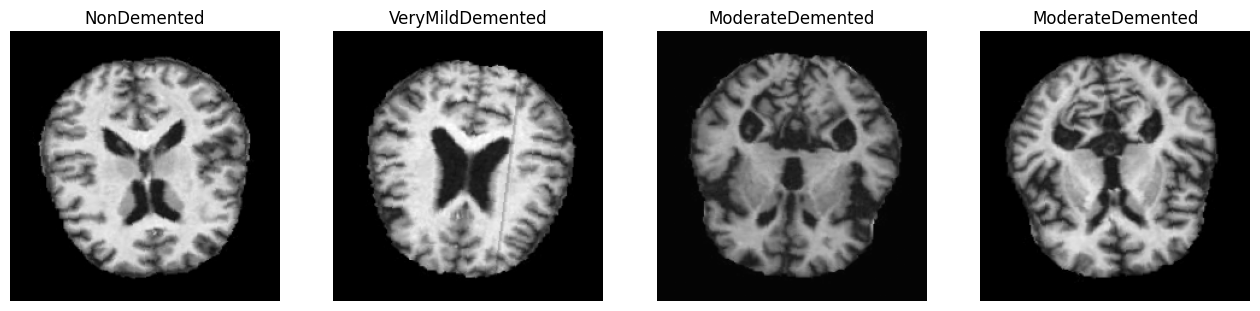

In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import random_split, DataLoader, WeightedRandomSampler, Subset

# ==========================================
# 1. CONFIGURATION & REPRODUCIBILITY
# ==========================================
DATA_DIR = '/kaggle/input/alzheimer-mri-4-classes-dataset/Alzheimer_MRI_4_classes_dataset'
BATCH_SIZE = 32
IMG_SIZE = 224
SEED = 42

# Ensure results are reproducible
torch.manual_seed(SEED)
np.random.seed(SEED)
fixed_generator = torch.Generator().manual_seed(SEED)

# ==========================================
# 2. ADVANCED PREPROCESSING PIPELINES
# ==========================================

# Training Pipeline: We "muscle" the AI with data augmentation
# This helps the model generalize and not memorize specific pixel positions.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),      # Left/Right symmetry
    transforms.RandomRotation(degrees=15),       # Small head tilts in the scanner
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Scanner intensity variations
    transforms.ToTensor(),
    # Standardization using ImageNet stats (required for EfficientNet)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test Pipeline: Must be "sterile"
# We only resize and normalize. No flipping or rotating here!
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 3. DATA LOADING & SAMPLING LOGIC
# ==========================================

# Helper class to apply different transforms to Subsets
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

try:
    # Load the full raw dataset
    full_dataset = ImageFolder(root=DATA_DIR)
    classes = full_dataset.classes
    
    # 80/20 Split
    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_indices, val_indices = random_split(
        full_dataset, [train_size, val_size], generator=fixed_generator
    )

    # Fix: Extract targets as a numpy array for robust counting
    train_targets = np.array([full_dataset.targets[i] for i in train_indices.indices])
    
    # Use bincount for efficient and warning-free counting
    class_sample_count = np.bincount(train_targets, minlength=len(classes))
    
    # If a class has 0 samples (shouldn't happen with 80/20), weight is 0
    weight = np.divide(1., class_sample_count, 
                       out=np.zeros_like(class_sample_count, dtype=float), 
                       where=class_sample_count != 0)
    
    samples_weight = torch.from_numpy(np.array([weight[t] for t in train_targets]))
    
    sampler = WeightedRandomSampler(
        weights=samples_weight, 
        num_samples=len(samples_weight), 
        replacement=True
    )

    # Apply specific transforms to each split
    train_data = TransformedSubset(train_indices, transform=train_transform)
    val_data = TransformedSubset(val_indices, transform=val_transform)

    # ==========================================
    # 4. OPTIMIZED DATALOADERS
    # ==========================================
    train_loader = DataLoader(
        train_data, 
        batch_size=BATCH_SIZE, 
        sampler=sampler,        # Uses our weighted strategy instead of shuffle=True
        num_workers=2,          # Parallel CPU prep
        pin_memory=True         # Faster transfer to GPU
    )

    test_loader = DataLoader(
        val_data, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=2,
        pin_memory=True
    )

    print(f"✅ Data Engineering Phase Complete.")
    print(f"Detected Classes: {classes}")
    print(f"Training samples: {len(train_data)} | Validation samples: {len(val_data)}")
    print(f"Class distribution in Train: {class_sample_count}")

except Exception as e:
    print(f"ERROR during data loading: {e}")

# ==========================================
# 5. VISUAL VERIFICATION
# ==========================================
def imshow(img, title):
    # Reverse normalization for human display: (img * std) + mean
    stds = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    means = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img = img * stds + means
    
    plt.imshow(np.transpose(img.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

if 'train_loader' in locals():
    # Grab one batch to verify the Sampler and Transforms work
    images, labels = next(iter(train_loader))
    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        imshow(images[i], classes[labels[i]])
    plt.show()

print("DataLoaders ready for week 2")